Mounted at /content/drive
Setup complete.

Master CSV: 5814 rows
Colored-paper rows: 2841
Columns used — lux: 'lux_C', label: 'surface', filename: 'image_path'

After filtering: 2374 images, 22 colors
Lux range: 51 – 1600

Extracting features from images...


  0%|          | 0/2374 [00:00<?, ?it/s]

Done. 2374 images | Skipped: 0
Feature vector sizes — RGB:12, HSV:12, Lab:12, All:52

Classes: 22 colors | Chance level: 0.045

PART 4: Full classifier benchmark (5-fold CV)
Classifier             Mean Acc      Std
------------------------------------------
k-NN (k=5)                0.784    0.012
SVM (RBF)                 0.876    0.012
Random Forest             0.883    0.016
Extra Trees               0.886    0.016
XGBoost                   0.883    0.017
LightGBM                  0.890    0.016
MLP (2 layers)            0.866    0.023

Best classifier: LightGBM


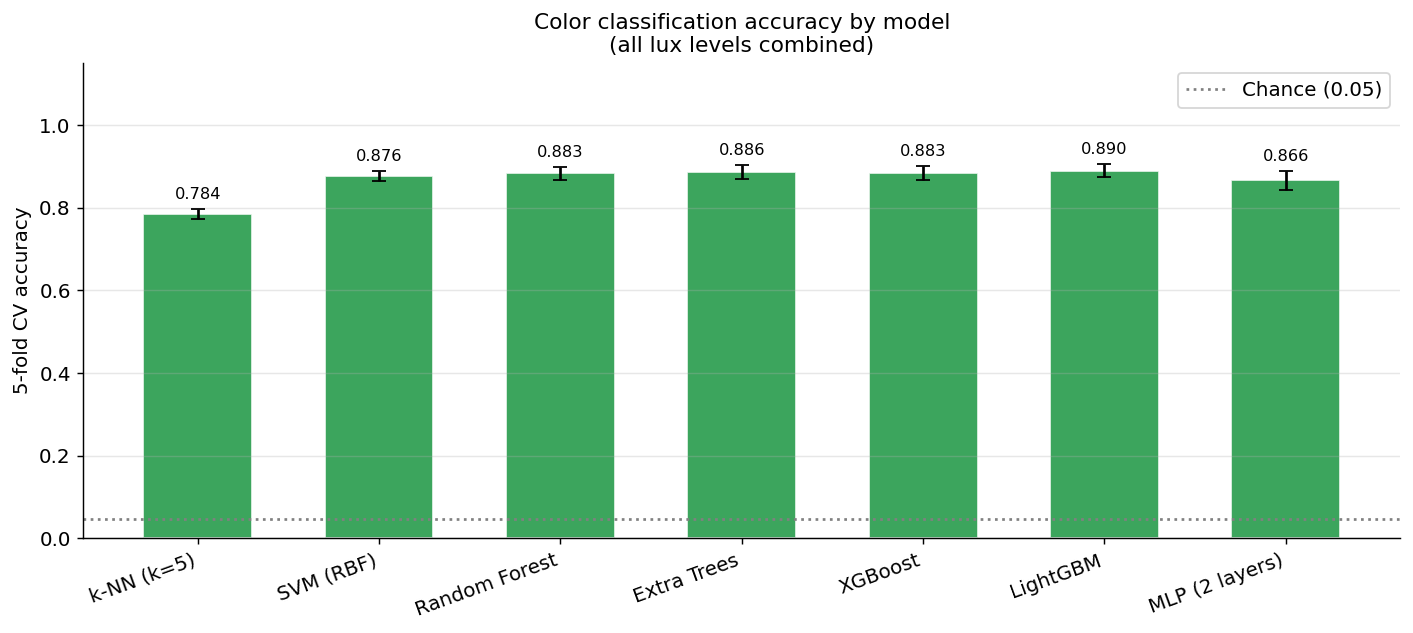

Saved: fig1_classifier_benchmark.png

PART 5: Feature ablation — which color space matters most?
Hypothesis: CIE Lab should outperform RGB at low lux because
L* captures brightness separately from a*/b* (color identity).

  RGB only       : 0.774 ± 0.016
  HSV only       : 0.903 ± 0.019
  Lab only       : 0.850 ± 0.012
  All features   : 0.886 ± 0.016
  RGB only   — high lux: 0.873, low lux: 0.758, drop: 0.115
  HSV only   — high lux: 0.960, low lux: 0.868, drop: 0.092
  Lab only   — high lux: 0.956, low lux: 0.812, drop: 0.144
  All        — high lux: 0.957, low lux: 0.857, drop: 0.100


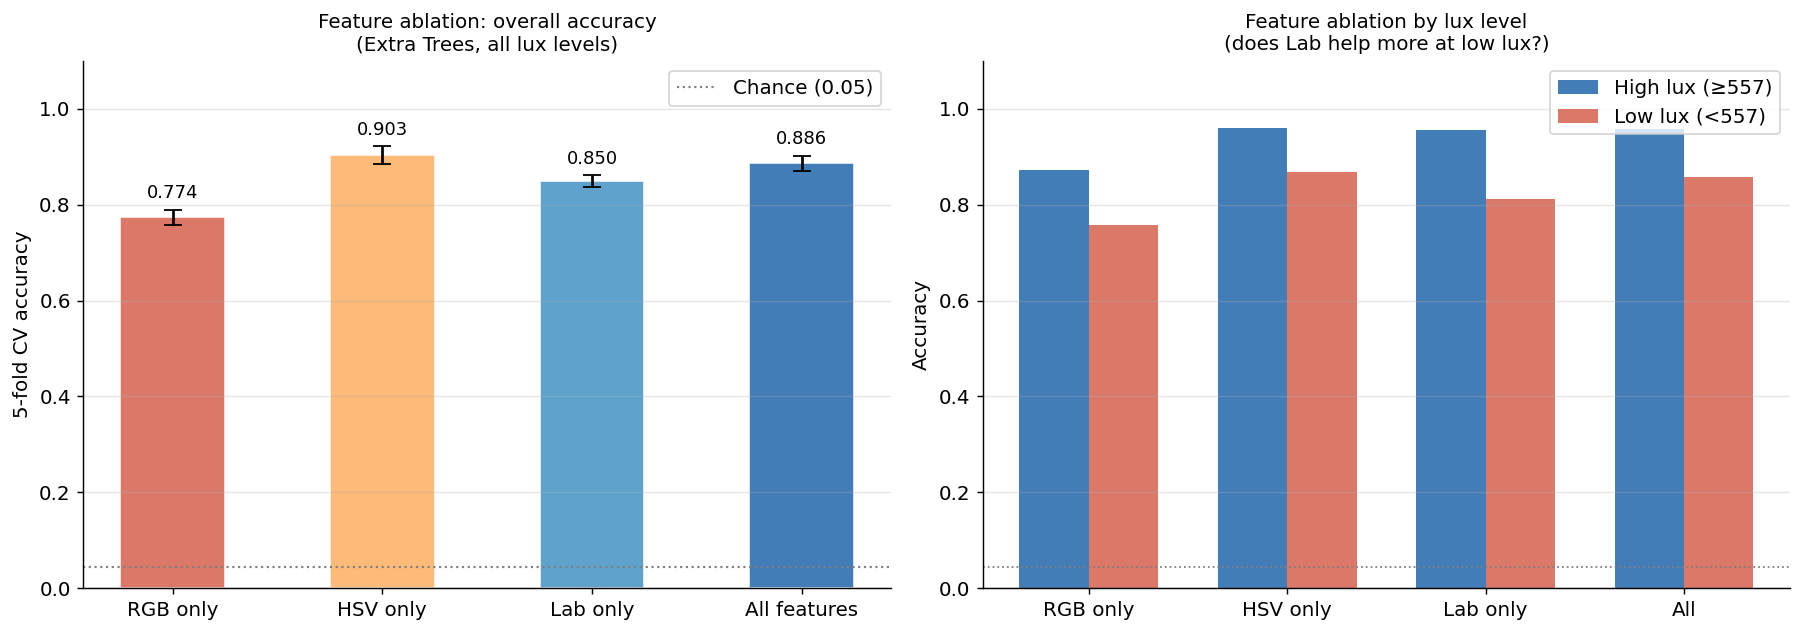

Saved: fig2_feature_ablation.png

PART 6: Regression — predict lux from color image features
Question: can we recover lux from features alone (no surface info)?
Hypothesis: L* channel (CIE Lab Lightness) should be most predictive.

Regressor                 MAE     RMSE       R2     MAPE
--------------------------------------------------------
k-NN (k=5)              112.0    171.8    0.692    21.9%
SVR (RBF)               122.1    183.9    0.648    28.4%
Random Forest           102.3    152.4    0.758     9.8%
Extra Trees              83.3    136.3    0.807     0.0%
XGBoost                  94.3    144.4    0.783     7.2%
LightGBM                 97.9    146.1    0.778    12.0%
MLP (2 layers)          114.7    168.7    0.704    20.0%

Best regressor: Extra Trees (R2=0.807)

Regression feature ablation (Extra Trees, 5-fold CV):
Feature set          MAE       R2
-----------------------------------
  RGB only     : MAE=102.1  R2=0.728
  HSV only     : MAE=88.5  R2=0.789
  Lab only     : 

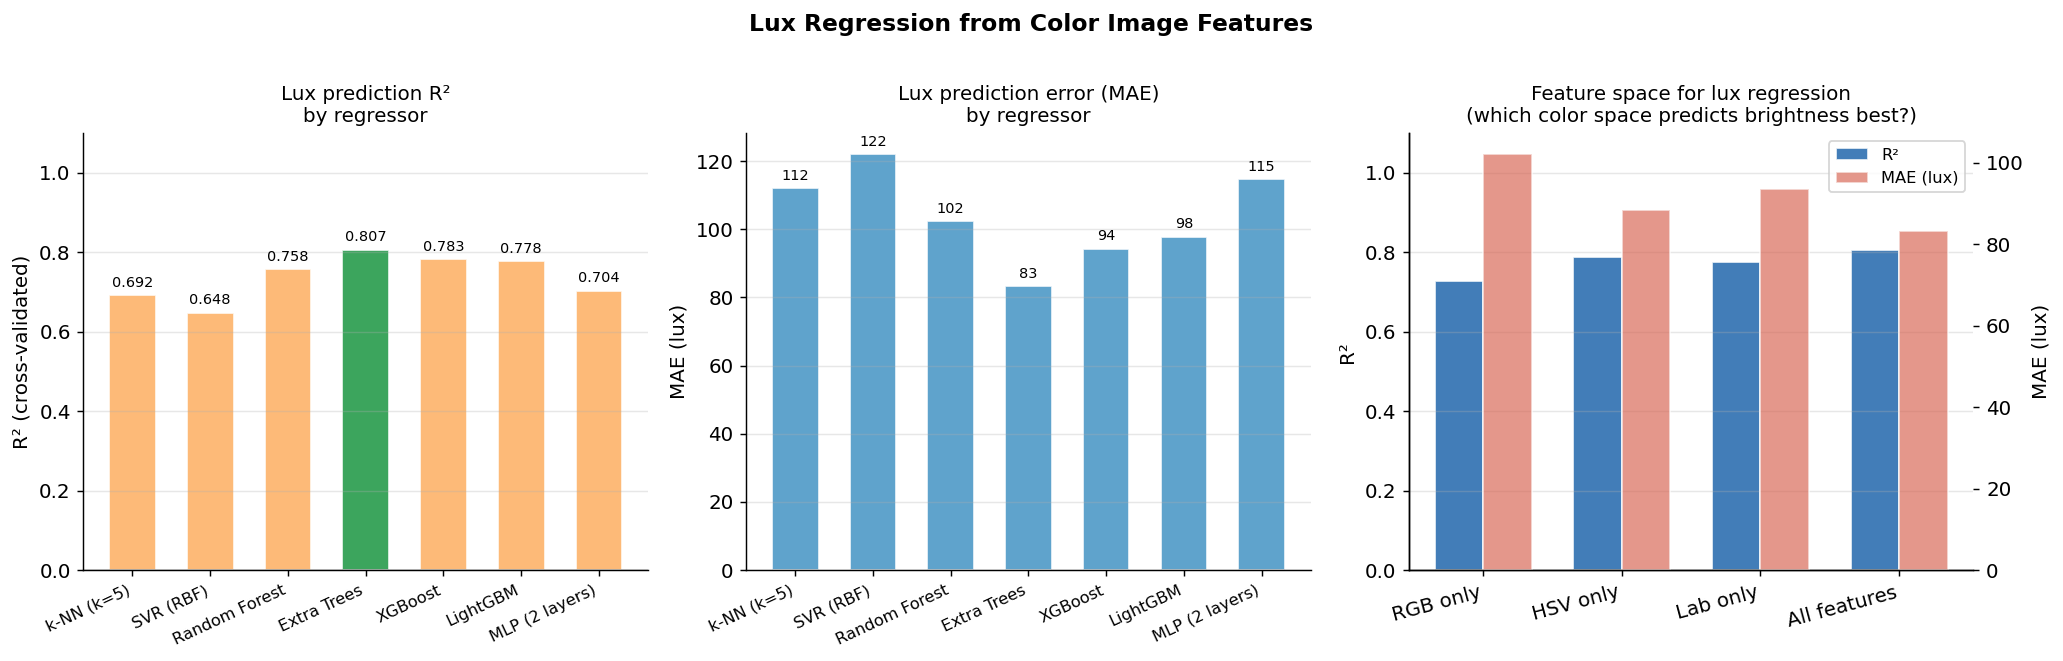

Saved: fig3_regression_results.png



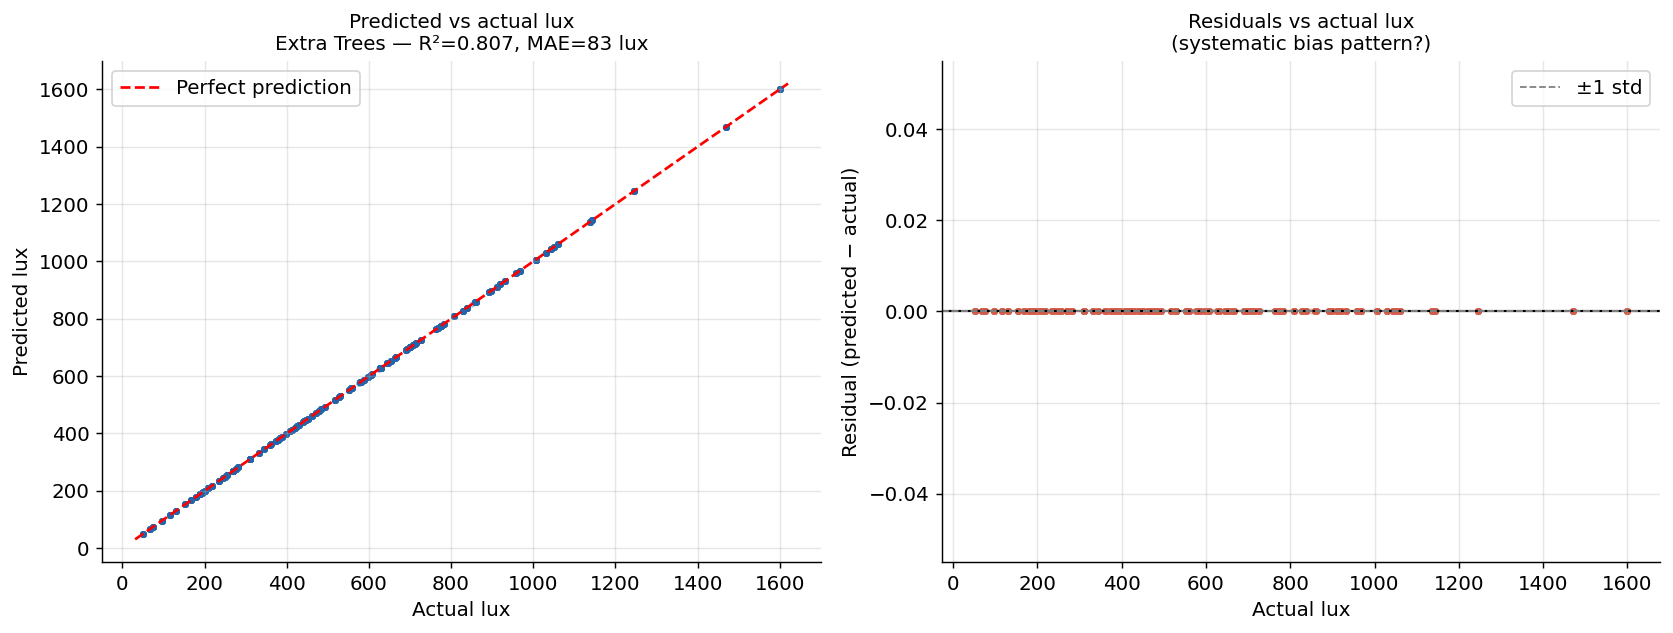

Saved: fig4_regression_scatter.png

Regression accuracy per color class (using best regressor):
  blush_paper              : MAE=0.0 lux, R2=1.000
  burgundy_paper           : MAE=0.0 lux, R2=1.000
  cool_red_paper           : MAE=0.0 lux, R2=1.000
  dark_burgundy_paper      : MAE=0.0 lux, R2=1.000
  dark_indigo_paper        : MAE=0.0 lux, R2=1.000
  deep_blue_paper          : MAE=0.0 lux, R2=1.000
  forest_green_paper       : MAE=0.0 lux, R2=1.000
  grass_green_paper        : MAE=0.0 lux, R2=1.000
  lavender_paper           : MAE=0.0 lux, R2=1.000
  light_green_paper        : MAE=0.0 lux, R2=1.000
  magenta_paper            : MAE=0.0 lux, R2=1.000
  maroon_paper             : MAE=0.0 lux, R2=1.000
  midnight_blue_paper      : MAE=0.0 lux, R2=1.000
  navy_blue_paper          : MAE=0.0 lux, R2=1.000
  orange_paper             : MAE=0.0 lux, R2=1.000
  purple_paper             : MAE=0.0 lux, R2=1.000
  red_paper                : MAE=0.0 lux, R2=1.000
  rose_paper               : MAE=0.0 

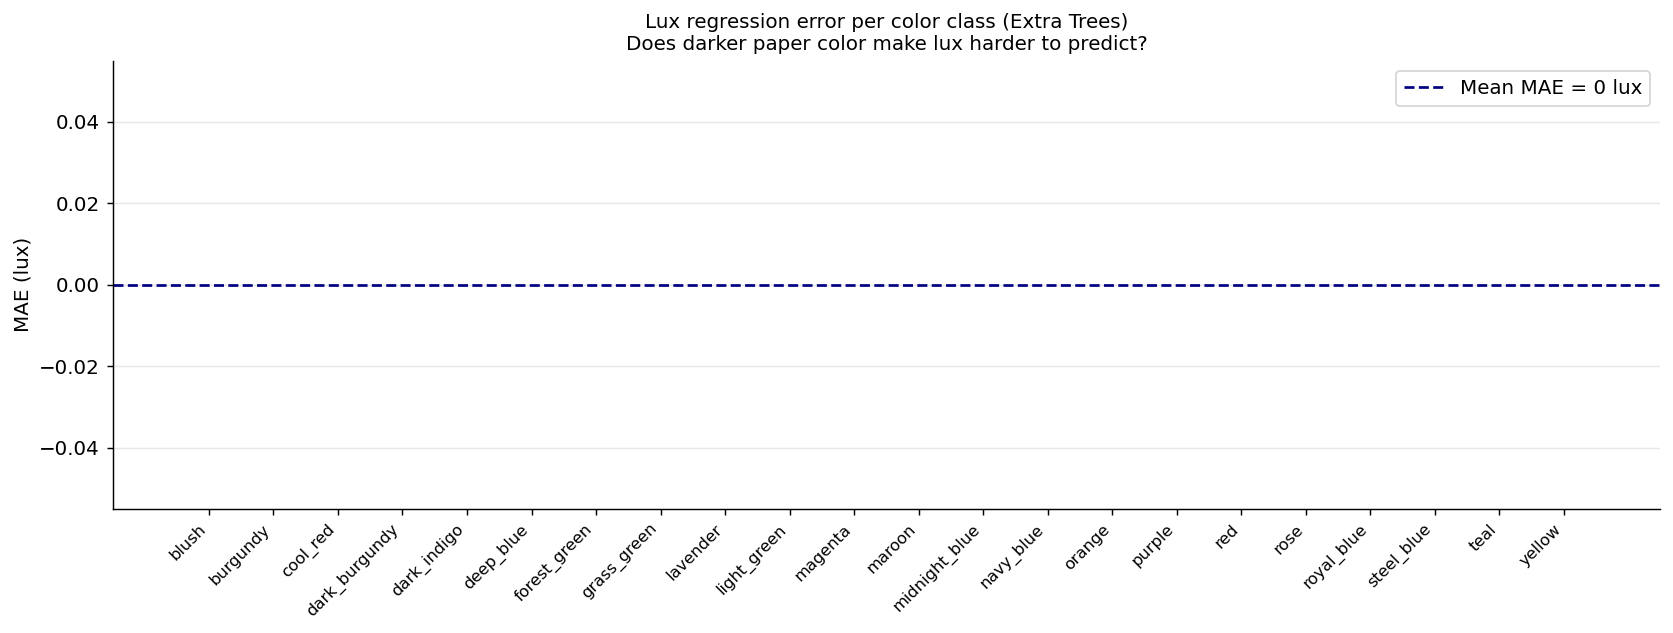

Saved: fig5_regression_per_color.png

All results saved to:
/content/drive/MyDrive/AI_Lux_Project/Experiments_ColorAnalysis_v3

=== DONE ===

╔══════════════════════════════════════════════════════════════╗
║  INTERPRETATION GUIDE                                        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Figure 1 — Classifier benchmark                            ║
║    Do XGBoost/LightGBM beat Random Forest?                  ║
║    How far above chance (1/22 = 4.5%)?                      ║
║                                                              ║
║  Figure 2 — Feature ablation                                ║
║    Does Lab accuracy DROP LESS at low lux than RGB?         ║
║    → if yes: Lab separates brightness from color identity   ║
║                                                              ║
║  Figure 3 — Regression summary                              ║
║    R2 > 0.7 = colo

In [ ]:

# ============================================================
#  AI LUX PROJECT — Extended Color Analysis  v3
#  Single-cell Google Colab script
#
#  NEW in this version vs v2:
#  A. Feature ablation: RGB vs HSV vs Lab vs All (classification)
#  B. XGBoost + LightGBM + MLP added to classifier benchmark
#  C. REGRESSION: predict lux value from color image features
#     (reverse question: can we tell how bright it is from the photo?)
#
#  Run time: ~60-80 min on Colab CPU
# ============================================================

# ── EDIT THESE ────────────────────────────────────────────────
PROJECT_ROOT        = '/content/drive/MyDrive/AI_Lux_Project'
DATABASE_DIR        = f'{PROJECT_ROOT}/Database'
MASTER_CSV          = f'{PROJECT_ROOT}/Dataset_Master/annotation_master_latest.csv'
OUTPUT_DIR          = f'{PROJECT_ROOT}/Experiments_ColorAnalysis_v3'

LUX_BIN_WIDTH       = 50
MIN_PER_BIN         = 15
TRAIN_LUX_THRESHOLD = 300
ROI_FRACTION        = 0.15

VALID_COLORS = {
    'blush_paper', 'burgundy_paper', 'cool_red_paper', 'dark_burgundy_paper',
    'dark_indigo_paper', 'deep_blue_paper', 'forest_green_paper', 'royal_blue_paper',
    'purple_paper', 'rose_paper', 'red_paper', 'teal_paper', 'steel_blue_paper',
    'navy_blue_paper', 'grass_green_paper', 'magenta_paper', 'light_green_paper',
    'lavender_paper', 'midnight_blue_paper', 'maroon_paper', 'orange_paper', 'yellow_paper'
}
# ──────────────────────────────────────────────────────────────

# ── Install extra libraries (not in Colab by default) ─────────
import subprocess, sys
for pkg in ['xgboost', 'lightgbm']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)

# ── Mount drive & imports ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.auto import tqdm
import cv2
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (StratifiedKFold, KFold,
                                     cross_val_score, cross_validate)
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              mean_absolute_error, mean_squared_error, r2_score,
                              confusion_matrix)
import xgboost as xgb
import lightgbm as lgb

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Setup complete.\n")

# ══════════════════════════════════════════════════════════════
# PART 1 — LOAD DATA
# ══════════════════════════════════════════════════════════════
df = pd.read_csv(MASTER_CSV)
print(f"Master CSV: {len(df)} rows")

df_color = df[df['surface_group_norm'] == 'colored_paper'].copy()
print(f"Colored-paper rows: {len(df_color)}")

lux_col   = next((c for c in ['lux_C','lux_center','LC','central_lux'] if c in df_color.columns), None)
label_col = next((c for c in ['surface','surface_norm'] if c in df_color.columns), None)
fname_col = next((c for c in ['image_path','filename','image_name','path'] if c in df_color.columns), None)
assert lux_col and label_col and fname_col, \
    f"Missing column. lux={lux_col}, label={label_col}, fname={fname_col}"
print(f"Columns used — lux: '{lux_col}', label: '{label_col}', filename: '{fname_col}'\n")

df_color['lux_center']  = pd.to_numeric(df_color[lux_col], errors='coerce')
df_color['color_label'] = df_color[label_col].astype(str).str.strip()
df_color = df_color[df_color['color_label'].isin(VALID_COLORS)].copy()
df_color = df_color.dropna(subset=['lux_center']).reset_index(drop=True)
print(f"After filtering: {len(df_color)} images, {df_color['color_label'].nunique()} colors")
print(f"Lux range: {df_color['lux_center'].min():.0f} – {df_color['lux_center'].max():.0f}\n")

# ══════════════════════════════════════════════════════════════
# PART 2 — IMAGE PATH RESOLUTION
# ══════════════════════════════════════════════════════════════
def resolve_path(fname):
    for c in [str(fname),
              os.path.join(DATABASE_DIR, str(fname)),
              os.path.join(DATABASE_DIR, Path(str(fname)).name)]:
        if os.path.isfile(c):
            return c
    return None

# ══════════════════════════════════════════════════════════════
# PART 3 — FEATURE EXTRACTION
# (returns separate arrays per color space for ablation study)
# ══════════════════════════════════════════════════════════════
def extract_all_features(img_path, roi_frac=ROI_FRACTION):
    """
    Returns dict with keys: 'rgb', 'hsv', 'lab', 'all'
    Each is a flat numpy array.

    Color spaces:
    - RGB: camera sensor response (red, green, blue channels)
    - HSV: Hue (color type), Saturation (color purity), Value (brightness)
    - Lab: L* = perceptual Lightness (most affected by lux),
           a* = green-red axis, b* = blue-yellow axis
           Lab separates brightness (L*) from color identity (a*, b*)
           → theoretically best for low-lux color recognition
    - Hue histogram: distribution of hue across ROI (16 bins)
    """
    try:
        img = cv2.imread(img_path)
        if img is None: return None
        h, w = img.shape[:2]
        cy, cx = h//2, w//2
        rh = max(1, int(h * roi_frac / 2))
        rw = max(1, int(w * roi_frac / 2))
        roi = img[cy-rh:cy+rh, cx-rw:cx+rw]

        def stats(arr2d):
            return [arr2d.mean(), arr2d.std(),
                    float(np.percentile(arr2d, 25)),
                    float(np.percentile(arr2d, 75))]

        # RGB
        rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        rgb_feats = []
        for c in range(3): rgb_feats += stats(rgb[:,:,c])

        # HSV
        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV).astype(np.float32)
        hsv[:,:,0] /= 180.0; hsv[:,:,1] /= 255.0; hsv[:,:,2] /= 255.0
        hsv_feats = []
        for c in range(3): hsv_feats += stats(hsv[:,:,c])

        # CIE Lab
        # L*: 0-100 (lightness — drops at low lux)
        # a*: 0-255 in OpenCV 8-bit (green↔red, 128 = neutral)
        # b*: 0-255 in OpenCV 8-bit (blue↔yellow, 128 = neutral)
        lab = cv2.cvtColor(roi, cv2.COLOR_BGR2Lab).astype(np.float32)
        lab[:,:,0] /= 100.0
        lab[:,:,1] /= 255.0
        lab[:,:,2] /= 255.0
        lab_feats = []
        for c in range(3): lab_feats += stats(lab[:,:,c])

        # Hue histogram
        hue_hist, _ = np.histogram(hsv[:,:,0].flatten(), bins=16, range=(0,1), density=True)

        rgb_arr = np.array(rgb_feats, dtype=np.float32)
        hsv_arr = np.array(hsv_feats, dtype=np.float32)
        lab_arr = np.array(lab_feats, dtype=np.float32)
        all_arr = np.concatenate([rgb_arr, hsv_arr, lab_arr, hue_hist.astype(np.float32)])

        return {'rgb': rgb_arr, 'hsv': hsv_arr, 'lab': lab_arr, 'all': all_arr}
    except:
        return None


print("Extracting features from images...")
all_feats, valid_idx, missing = [], [], 0
for idx, row in tqdm(df_color.iterrows(), total=len(df_color)):
    p = resolve_path(row[fname_col])
    if p is None: missing += 1; continue
    f = extract_all_features(p)
    if f is None: missing += 1; continue
    all_feats.append(f)
    valid_idx.append(idx)

df_color = df_color.loc[valid_idx].reset_index(drop=True)
lux_vals  = df_color['lux_center'].values.astype(float)

X_all = np.array([f['all'] for f in all_feats])
X_rgb = np.array([f['rgb'] for f in all_feats])
X_hsv = np.array([f['hsv'] for f in all_feats])
X_lab = np.array([f['lab'] for f in all_feats])

print(f"Done. {len(df_color)} images | Skipped: {missing}")
print(f"Feature vector sizes — RGB:{X_rgb.shape[1]}, HSV:{X_hsv.shape[1]}, "
      f"Lab:{X_lab.shape[1]}, All:{X_all.shape[1]}\n")

le = LabelEncoder()
y_cls = le.fit_transform(df_color['color_label'])
y_reg = lux_vals.copy()

def scale(Xr): return StandardScaler().fit_transform(Xr)
X = scale(X_all)

chance = 1 / len(le.classes_)
print(f"Classes: {len(le.classes_)} colors | Chance level: {chance:.3f}\n")

# ══════════════════════════════════════════════════════════════
# PART 4 — FULL CLASSIFIER BENCHMARK (incl. XGBoost, LightGBM, MLP)
# ══════════════════════════════════════════════════════════════
print("="*60)
print("PART 4: Full classifier benchmark (5-fold CV)")
print("="*60)

classifiers = {
    'k-NN (k=5)'      : KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)'       : SVC(kernel='rbf', C=10, gamma='scale'),
    'Random Forest'   : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Extra Trees'     : ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost'         : xgb.XGBClassifier(n_estimators=200, learning_rate=0.1,
                                           max_depth=6, use_label_encoder=False,
                                           eval_metric='mlogloss', random_state=42,
                                           n_jobs=-1, verbosity=0),
    'LightGBM'        : lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1,
                                            max_depth=6, random_state=42,
                                            n_jobs=-1, verbose=-1),
    'MLP (2 layers)'  : MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500,
                                      random_state=42, early_stopping=True),
}

cv_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_results = {}
print(f"{'Classifier':<20} {'Mean Acc':>10} {'Std':>8}")
print('-'*42)
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X, y_cls, cv=cv_cls, scoring='accuracy', n_jobs=-1)
    clf_results[name] = scores
    print(f"{name:<20} {scores.mean():>10.3f} {scores.std():>8.3f}")

best_clf_name = max(clf_results, key=lambda k: clf_results[k].mean())
print(f"\nBest classifier: {best_clf_name}")

# ── Figure 1: Classifier comparison bar chart ──────────────────
fig, ax = plt.subplots(figsize=(11, 5))
names = list(clf_results.keys())
means = [clf_results[n].mean() for n in names]
stds  = [clf_results[n].std()  for n in names]
colors_bar = ['#d73027' if m < 0.5 else '#fdae61' if m < 0.7 else '#1a9641' for m in means]
bars = ax.bar(names, means, yerr=stds, capsize=4, color=colors_bar, alpha=0.85,
              edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='{:.3f}', padding=4, fontsize=9)
ax.axhline(chance, color='gray', ls=':', lw=1.5, label=f'Chance ({chance:.2f})')
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Color classification accuracy by model\n(all lux levels combined)', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig1_classifier_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_classifier_benchmark.png\n")

# ══════════════════════════════════════════════════════════════
# PART 5 — FEATURE ABLATION (classification)
# Which color space best predicts color under varying lux?
# ══════════════════════════════════════════════════════════════
print("="*60)
print("PART 5: Feature ablation — which color space matters most?")
print("="*60)
print("Hypothesis: CIE Lab should outperform RGB at low lux because")
print("L* captures brightness separately from a*/b* (color identity).\n")

ablation = {}
for space_name, Xf in [('RGB only',    X_rgb),
                        ('HSV only',    X_hsv),
                        ('Lab only',    X_lab),
                        ('All features', X_all)]:
    Xfs = scale(Xf)
    clf_abl = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    scores = cross_val_score(clf_abl, Xfs, y_cls, cv=cv_cls, scoring='accuracy', n_jobs=-1)
    ablation[space_name] = (scores.mean(), scores.std())
    print(f"  {space_name:<15}: {scores.mean():.3f} ± {scores.std():.3f}")

# Also do ablation stratified by lux level (high vs low)
median_lux = np.median(lux_vals)
hi_mask = lux_vals >= median_lux
lo_mask = ~hi_mask

ablation_lux = {}
for space_name, Xf in [('RGB only', X_rgb), ('HSV only', X_hsv),
                        ('Lab only', X_lab), ('All', X_all)]:
    Xfs = scale(Xf)
    # High-lux accuracy
    scores_hi = cross_val_score(ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                                 Xfs[hi_mask], y_cls[hi_mask], cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                 scoring='accuracy')
    # Low-lux accuracy
    scores_lo = cross_val_score(ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                                 Xfs[lo_mask], y_cls[lo_mask], cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                 scoring='accuracy')
    ablation_lux[space_name] = (scores_hi.mean(), scores_lo.mean())
    print(f"  {space_name:<10} — high lux: {scores_hi.mean():.3f}, low lux: {scores_lo.mean():.3f}, "
          f"drop: {scores_hi.mean()-scores_lo.mean():.3f}")

# ── Figure 2: Ablation results ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
space_names = list(ablation.keys())
abl_means = [ablation[n][0] for n in space_names]
abl_stds  = [ablation[n][1] for n in space_names]
clrs = ['#d6604d','#fdae61','#4393c3','#2166ac']
bars = ax.bar(space_names, abl_means, yerr=abl_stds, capsize=5, color=clrs,
              alpha=0.85, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='{:.3f}', padding=4, fontsize=10)
ax.axhline(chance, color='gray', ls=':', lw=1.2, label=f'Chance ({chance:.2f})')
ax.set_title('Feature ablation: overall accuracy\n(Extra Trees, all lux levels)', fontsize=11)
ax.set_ylabel('5-fold CV accuracy')
ax.set_ylim(0, 1.1); ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
abl_names  = list(ablation_lux.keys())
hi_accs    = [ablation_lux[n][0] for n in abl_names]
lo_accs    = [ablation_lux[n][1] for n in abl_names]
xi = np.arange(len(abl_names)); w = 0.35
ax.bar(xi - w/2, hi_accs, w, label=f'High lux (≥{median_lux:.0f})',
       color='#2166ac', alpha=0.85)
ax.bar(xi + w/2, lo_accs, w, label=f'Low lux (<{median_lux:.0f})',
       color='#d6604d', alpha=0.85)
ax.set_xticks(xi); ax.set_xticklabels(abl_names)
ax.set_title('Feature ablation by lux level\n(does Lab help more at low lux?)', fontsize=11)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.1); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.axhline(chance, color='gray', ls=':', lw=1)

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig2_feature_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_feature_ablation.png\n")

# ══════════════════════════════════════════════════════════════
# PART 6 — REGRESSION: predict lux from color image features
#
# Scientific question: can we estimate HOW BRIGHT the light is
# just by looking at a colored paper photo — without knowing
# what color the paper is?
#
# This is the inverse of the main project (which uses lux to
# understand the image), but it tests whether color features
# carry enough brightness information to recover lux.
# ══════════════════════════════════════════════════════════════
print("="*60)
print("PART 6: Regression — predict lux from color image features")
print("="*60)
print("Question: can we recover lux from features alone (no surface info)?")
print("Hypothesis: L* channel (CIE Lab Lightness) should be most predictive.\n")

regressors = {
    'k-NN (k=5)'     : KNeighborsRegressor(n_neighbors=5),
    'SVR (RBF)'      : SVR(kernel='rbf', C=100, gamma='scale'),
    'Random Forest'  : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Extra Trees'    : ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost'        : xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                                         random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM'       : lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                                          random_state=42, n_jobs=-1, verbose=-1),
    'MLP (2 layers)' : MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500,
                                    random_state=42, early_stopping=True),
}

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
reg_results = {}
print(f"{'Regressor':<20} {'MAE':>8} {'RMSE':>8} {'R2':>8} {'MAPE':>8}")
print('-'*56)

for name, reg in regressors.items():
    cv_out = cross_validate(reg, X, y_reg, cv=cv_reg,
                             scoring=['neg_mean_absolute_error',
                                      'neg_root_mean_squared_error',
                                      'r2'],
                             n_jobs=-1)
    mae  = -cv_out['test_neg_mean_absolute_error'].mean()
    rmse = -cv_out['test_neg_root_mean_squared_error'].mean()
    r2   =  cv_out['test_r2'].mean()
    # MAPE manually
    reg_clone = type(reg)(**reg.get_params())
    reg_clone.fit(X, y_reg)
    yp = reg_clone.predict(X)
    mape = np.mean(np.abs((y_reg - yp) / y_reg)) * 100
    reg_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}
    print(f"{name:<20} {mae:>8.1f} {rmse:>8.1f} {r2:>8.3f} {mape:>7.1f}%")

best_reg_name = max(reg_results, key=lambda k: reg_results[k]['R2'])
print(f"\nBest regressor: {best_reg_name} (R2={reg_results[best_reg_name]['R2']:.3f})")

# ── Regression: feature ablation (which space is most predictive for lux?) ─
print("\nRegression feature ablation (Extra Trees, 5-fold CV):")
print(f"{'Feature set':<15} {'MAE':>8} {'R2':>8}")
print('-'*35)
reg_ablation = {}
for space_name, Xf in [('RGB only', X_rgb), ('HSV only', X_hsv),
                        ('Lab only', X_lab), ('All features', X_all)]:
    Xfs = scale(Xf)
    reg_abl = ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    cv_out  = cross_validate(reg_abl, Xfs, y_reg, cv=cv_reg,
                              scoring=['neg_mean_absolute_error', 'r2'], n_jobs=-1)
    mae = -cv_out['test_neg_mean_absolute_error'].mean()
    r2  =  cv_out['test_r2'].mean()
    reg_ablation[space_name] = (mae, r2)
    print(f"  {space_name:<13}: MAE={mae:.1f}  R2={r2:.3f}")

# ── Figure 3: Regression results ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: R2 by regressor
ax = axes[0]
reg_names = list(reg_results.keys())
r2_vals   = [reg_results[n]['R2'] for n in reg_names]
mae_vals  = [reg_results[n]['MAE'] for n in reg_names]
clrs_r2 = ['#1a9641' if v > 0.8 else '#fdae61' if v > 0.5 else '#d73027' for v in r2_vals]
bars = ax.bar(reg_names, r2_vals, color=clrs_r2, alpha=0.85, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='{:.3f}', padding=3, fontsize=8)
ax.set_xticklabels(reg_names, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('R² (cross-validated)')
ax.set_title('Lux prediction R²\nby regressor', fontsize=11)
ax.set_ylim(0, 1.1); ax.axhline(0, color='gray', lw=0.8); ax.grid(axis='y', alpha=0.3)

# Middle: MAE by regressor
ax = axes[1]
bars = ax.bar(reg_names, mae_vals, color='#4393c3', alpha=0.85, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='{:.0f}', padding=3, fontsize=8)
ax.set_xticklabels(reg_names, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('MAE (lux)')
ax.set_title('Lux prediction error (MAE)\nby regressor', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Right: Regression ablation (which color space for lux?)
ax = axes[2]
abl_r2   = [reg_ablation[n][1] for n in reg_ablation]
abl_mae  = [reg_ablation[n][0] for n in reg_ablation]
xi = np.arange(len(reg_ablation)); w = 0.35
ax2 = ax.twinx()
bars1 = ax.bar(xi - w/2, abl_r2,  w, color='#2166ac', alpha=0.85, label='R²', edgecolor='white')
bars2 = ax2.bar(xi + w/2, abl_mae, w, color='#d6604d', alpha=0.65, label='MAE (lux)', edgecolor='white')
ax.set_xticks(xi); ax.set_xticklabels(list(reg_ablation.keys()), rotation=15, ha='right')
ax.set_ylabel('R²'); ax2.set_ylabel('MAE (lux)')
ax.set_title('Feature space for lux regression\n(which color space predicts brightness best?)', fontsize=11)
ax.set_ylim(0, 1.1); ax.grid(axis='y', alpha=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.suptitle('Lux Regression from Color Image Features', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig3_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig3_regression_results.png\n")

# ── Figure 4: Predicted vs actual lux (best regressor) ────────
best_reg = regressors[best_reg_name]
best_reg.fit(X, y_reg)
y_pred_best = best_reg.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_reg, y_pred_best, alpha=0.2, s=8, color='#2166ac', rasterized=True)
lims = [min(y_reg.min(), y_pred_best.min()) - 20,
        max(y_reg.max(), y_pred_best.max()) + 20]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual lux'); ax.set_ylabel('Predicted lux')
ax.set_title(f'Predicted vs actual lux\n{best_reg_name} — '
             f'R²={reg_results[best_reg_name]["R2"]:.3f}, '
             f'MAE={reg_results[best_reg_name]["MAE"]:.0f} lux', fontsize=11)
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
residuals = y_pred_best - y_reg
ax.scatter(y_reg, residuals, alpha=0.2, s=8, color='#d6604d', rasterized=True)
ax.axhline(0, color='black', lw=1.2)
ax.axhline( residuals.std(), color='gray', ls='--', lw=1, label='±1 std')
ax.axhline(-residuals.std(), color='gray', ls='--', lw=1)
ax.set_xlabel('Actual lux'); ax.set_ylabel('Residual (predicted − actual)')
ax.set_title('Residuals vs actual lux\n(systematic bias pattern?)', fontsize=11)
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig4_regression_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_regression_scatter.png\n")

# ── Figure 5: Regression by color — does color matter? ────────
# Does the model predict lux better for bright colors (yellow, orange)
# than for dark colors (dark indigo, maroon)?
print("Regression accuracy per color class (using best regressor):")
per_color_reg = {}
for ci, cn in enumerate(le.classes_):
    mask = (y_cls == ci)
    if mask.sum() < 5: continue
    yp_c = best_reg.predict(X[mask])
    mae_c = mean_absolute_error(y_reg[mask], yp_c)
    r2_c  = r2_score(y_reg[mask], yp_c) if mask.sum() > 2 else np.nan
    per_color_reg[cn] = (mae_c, r2_c)
    print(f"  {cn:<25}: MAE={mae_c:.1f} lux, R2={r2_c:.3f}")

sorted_colors = sorted(per_color_reg, key=lambda c: per_color_reg[c][0])
fig, ax = plt.subplots(figsize=(13, 5))
short = [c.replace('_paper','') for c in sorted_colors]
mae_per_c = [per_color_reg[c][0] for c in sorted_colors]
clrs_c = plt.cm.RdYlGn_r(np.linspace(0, 1, len(sorted_colors)))
bars = ax.bar(short, mae_per_c, color=clrs_c, edgecolor='white', alpha=0.9)
ax.set_xticklabels(short, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('MAE (lux)')
ax.set_title(f'Lux regression error per color class ({best_reg_name})\n'
             'Does darker paper color make lux harder to predict?', fontsize=11)
ax.axhline(np.mean(mae_per_c), color='navy', ls='--', lw=1.5,
           label=f'Mean MAE = {np.mean(mae_per_c):.0f} lux')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig5_regression_per_color.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig5_regression_per_color.png\n")

# ══════════════════════════════════════════════════════════════
# PART 7 — SAVE RESULTS TO CSV
# ══════════════════════════════════════════════════════════════
pd.DataFrame({
    'classifier'   : list(clf_results.keys()),
    'mean_accuracy': [clf_results[n].mean() for n in clf_results],
    'std_accuracy' : [clf_results[n].std()  for n in clf_results],
}).to_csv(f'{OUTPUT_DIR}/results_classifiers.csv', index=False)

pd.DataFrame({
    'regressor': list(reg_results.keys()),
    'MAE'      : [reg_results[n]['MAE']  for n in reg_results],
    'RMSE'     : [reg_results[n]['RMSE'] for n in reg_results],
    'R2'       : [reg_results[n]['R2']   for n in reg_results],
    'MAPE_pct' : [reg_results[n]['MAPE'] for n in reg_results],
}).to_csv(f'{OUTPUT_DIR}/results_regression.csv', index=False)

pd.DataFrame({
    'feature_set'      : list(ablation.keys()),
    'clf_accuracy'     : [ablation[n][0]      for n in ablation],
    'reg_MAE'          : [reg_ablation[n][0]  for n in reg_ablation],
    'reg_R2'           : [reg_ablation[n][1]  for n in reg_ablation],
}).to_csv(f'{OUTPUT_DIR}/results_ablation.csv', index=False)

pd.DataFrame([
    {'color': c, 'regression_MAE': per_color_reg[c][0], 'regression_R2': per_color_reg[c][1]}
    for c in sorted_colors
]).to_csv(f'{OUTPUT_DIR}/results_regression_per_color.csv', index=False)

print(f"All results saved to:\n{OUTPUT_DIR}")
print("\n=== DONE ===")
print("""
╔══════════════════════════════════════════════════════════════╗
║  INTERPRETATION GUIDE                                        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Figure 1 — Classifier benchmark                            ║
║    Do XGBoost/LightGBM beat Random Forest?                  ║
║    How far above chance (1/22 = 4.5%)?                      ║
║                                                              ║
║  Figure 2 — Feature ablation                                ║
║    Does Lab accuracy DROP LESS at low lux than RGB?         ║
║    → if yes: Lab separates brightness from color identity   ║
║                                                              ║
║  Figure 3 — Regression summary                              ║
║    R2 > 0.7 = color features carry brightness signal        ║
║    R2 < 0.3 = color alone cannot predict lux                ║
║    Which color space best predicts lux?                     ║
║                                                              ║
║  Figure 4 — Scatter plot                                    ║
║    Systematic bias? (overestimate low lux, underestimate    ║
║    high lux = common regression-to-mean artifact)           ║
║                                                              ║
║  Figure 5 — Regression per color                            ║
║    Dark colors (maroon, dark indigo): higher MAE?           ║
║    Bright colors (yellow, orange): lower MAE?               ║
╚══════════════════════════════════════════════════════════════╝
""")

In [ ]:

# ── Mount drive & imports ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 2374 images, 22 colors
Extracting features...


  0%|          | 0/2374 [00:00<?, ?it/s]

Ready: 2374 images, feature matrix (2374, 52)

Color                         N    MAE (lux)       R²
-------------------------------------------------------
  blush_paper               108         31.9    0.968
  burgundy_paper            108         49.0    0.927
  cool_red_paper            108         37.0    0.959
  dark_burgundy_paper       108         57.8    0.891
  dark_indigo_paper         108         42.1    0.951
  deep_blue_paper           108         43.9    0.939
  forest_green_paper        108         45.6    0.934
  grass_green_paper         107         35.9    0.964
  lavender_paper            107         40.6    0.956
  light_green_paper         107         34.7    0.971
  magenta_paper             107         36.4    0.956
  maroon_paper              106         51.2    0.913
  midnight_blue_paper       107         66.6    0.879
  navy_blue_paper           107         57.8    0.903
  orange_paper              109         32.6    0.967
  purple_paper              108  

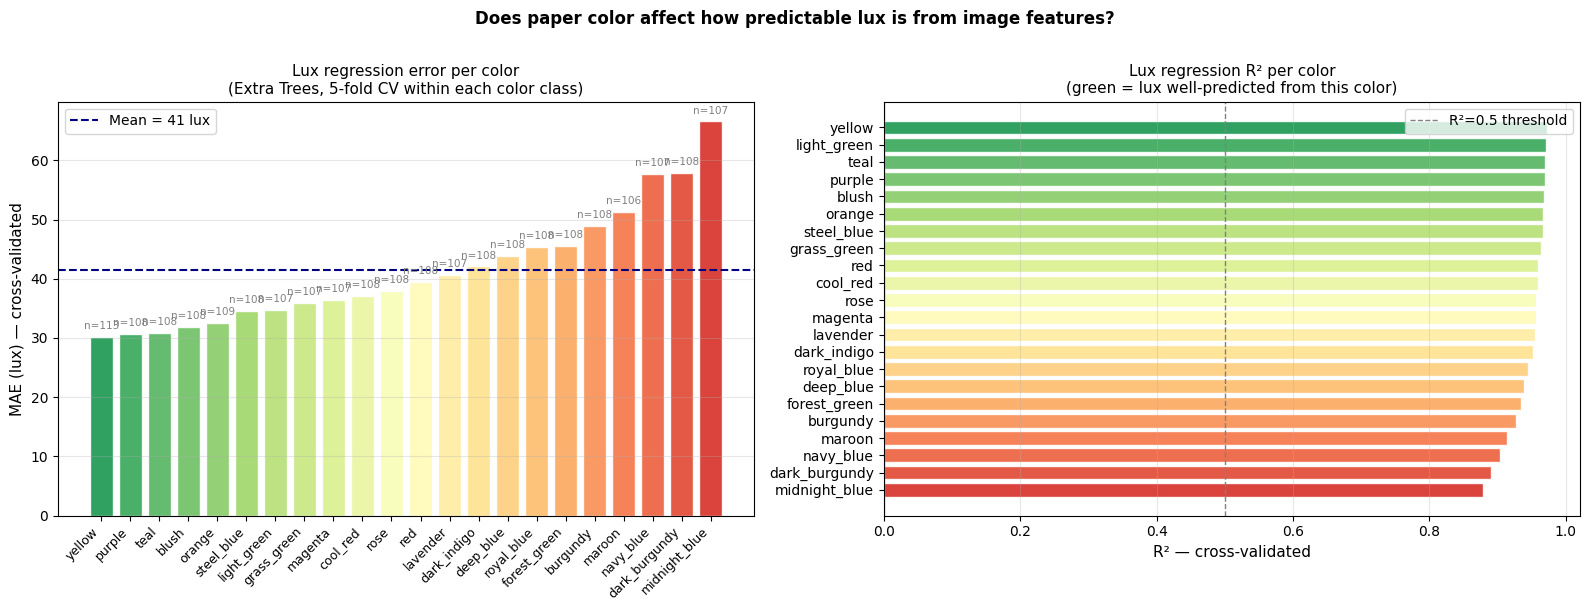

Saved: fig5_regression_per_color_FIXED.png
Saved: results_regression_per_color_FIXED.csv

Done.


In [ ]:
# ============================================================
#  Per-color lux regression — self-contained fix cell
#  Reloads everything from scratch, no dependency on v3 session
# ============================================================

# ── EDIT THESE (same as v3) ───────────────────────────────────
PROJECT_ROOT = '/content/drive/MyDrive/AI_Lux_Project'
DATABASE_DIR = f'{PROJECT_ROOT}/Database'
MASTER_CSV   = f'{PROJECT_ROOT}/Dataset_Master/annotation_master_latest.csv'
OUTPUT_DIR   = f'{PROJECT_ROOT}/Experiments_ColorAnalysis_v3'
ROI_FRACTION = 0.15

VALID_COLORS = {
    'blush_paper', 'burgundy_paper', 'cool_red_paper', 'dark_burgundy_paper',
    'dark_indigo_paper', 'deep_blue_paper', 'forest_green_paper', 'royal_blue_paper',
    'purple_paper', 'rose_paper', 'red_paper', 'teal_paper', 'steel_blue_paper',
    'navy_blue_paper', 'grass_green_paper', 'magenta_paper', 'light_green_paper',
    'lavender_paper', 'midnight_blue_paper', 'maroon_paper', 'orange_paper', 'yellow_paper'
}
# ─────────────────────────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import cv2
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────
df = pd.read_csv(MASTER_CSV)
df = df[df['surface_group_norm'] == 'colored_paper'].copy()
df['lux_center']  = pd.to_numeric(df['lux_C'], errors='coerce')
df['color_label'] = df['surface'].astype(str).str.strip()
df = df[df['color_label'].isin(VALID_COLORS)].dropna(subset=['lux_center']).reset_index(drop=True)
print(f"Loaded {len(df)} images, {df['color_label'].nunique()} colors")

# ── Resolve image paths ───────────────────────────────────────
fname_col = 'image_path'
def resolve(fname):
    for c in [str(fname), os.path.join(DATABASE_DIR, str(fname)),
              os.path.join(DATABASE_DIR, Path(str(fname)).name)]:
        if os.path.isfile(c): return c
    return None

# ── Feature extraction ────────────────────────────────────────
def extract(img_path):
    try:
        img = cv2.imread(img_path)
        if img is None: return None
        h, w = img.shape[:2]
        cy, cx = h//2, w//2
        rh = max(1, int(h*ROI_FRACTION/2))
        rw = max(1, int(w*ROI_FRACTION/2))
        roi = img[cy-rh:cy+rh, cx-rw:cx+rw]
        feats = []
        for conv, divs in [(cv2.COLOR_BGR2RGB,[255,255,255]),
                           (cv2.COLOR_BGR2HSV,[180,255,255]),
                           (cv2.COLOR_BGR2Lab,[100,255,255])]:
            ch = cv2.cvtColor(roi, conv).astype(np.float32)
            for c in range(3):
                ch[:,:,c] /= divs[c]
                arr = ch[:,:,c]
                feats += [arr.mean(), arr.std(),
                          float(np.percentile(arr,25)),
                          float(np.percentile(arr,75))]
        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV).astype(np.float32)
        hist, _ = np.histogram(hsv[:,:,0]/180, bins=16, range=(0,1), density=True)
        feats += list(hist)
        return np.array(feats, dtype=np.float32)
    except: return None

print("Extracting features...")
feats_list, valid_idx = [], []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    p = resolve(row[fname_col])
    if p is None: continue
    f = extract(p)
    if f is None: continue
    feats_list.append(f)
    valid_idx.append(idx)

df = df.loc[valid_idx].reset_index(drop=True)
X_raw = np.array(feats_list)
X = StandardScaler().fit_transform(X_raw)
y_reg = df['lux_center'].values.astype(float)

le = LabelEncoder()
y_cls = le.fit_transform(df['color_label'])
print(f"Ready: {len(df)} images, feature matrix {X.shape}\n")

# ── Per-color cross-validated regression ─────────────────────
print(f"{'Color':<25} {'N':>5} {'MAE (lux)':>12} {'R²':>8}")
print('-'*55)

per_color_cv = {}
MIN_N = 20

for ci, cn in enumerate(le.classes_):
    mask = (y_cls == ci)
    n = int(mask.sum())
    if n < MIN_N:
        print(f"  {cn:<23} {n:>5}   (skipped — < {MIN_N} samples)")
        continue
    X_c, y_c = X[mask], y_reg[mask]
    n_folds = min(5, n // 4)
    if n_folds < 2: continue
    reg = ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    y_pred = cross_val_predict(reg, X_c, y_c,
                                cv=KFold(n_splits=n_folds, shuffle=True, random_state=42))
    mae = mean_absolute_error(y_c, y_pred)
    r2  = r2_score(y_c, y_pred)
    per_color_cv[cn] = {'n': n, 'MAE': mae, 'R2': r2}
    print(f"  {cn:<23} {n:>5} {mae:>12.1f} {r2:>8.3f}")

# ── Plot ──────────────────────────────────────────────────────
sorted_by_mae = sorted(per_color_cv, key=lambda c: per_color_cv[c]['MAE'])
sorted_by_r2  = sorted(per_color_cv, key=lambda c: per_color_cv[c]['R2'])

mae_vals  = [per_color_cv[c]['MAE'] for c in sorted_by_mae]
r2_vals   = [per_color_cv[c]['R2']  for c in sorted_by_r2]
lbl_mae   = [c.replace('_paper','') for c in sorted_by_mae]
lbl_r2    = [c.replace('_paper','') for c in sorted_by_r2]
n_vals    = [per_color_cv[c]['n']   for c in sorted_by_mae]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
cmap = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(sorted_by_mae)))
bars = ax.bar(lbl_mae, mae_vals, color=cmap, edgecolor='white', alpha=0.9)
for bar, n in zip(bars, n_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'n={n}', ha='center', va='bottom', fontsize=7.5, color='gray')
ax.set_xticklabels(lbl_mae, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('MAE (lux) — cross-validated', fontsize=11)
ax.axhline(np.mean(mae_vals), color='navy', ls='--', lw=1.5,
           label=f'Mean = {np.mean(mae_vals):.0f} lux')
ax.set_title('Lux regression error per color\n'
             '(Extra Trees, 5-fold CV within each color class)', fontsize=11)
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
cmap2 = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(sorted_by_r2)))
ax.barh(lbl_r2, r2_vals, color=cmap2, edgecolor='white', alpha=0.9)
ax.axvline(0,   color='black', lw=0.8)
ax.axvline(0.5, color='gray',  ls='--', lw=1, label='R²=0.5 threshold')
ax.set_xlabel('R² — cross-validated', fontsize=11)
ax.set_title('Lux regression R² per color\n'
             '(green = lux well-predicted from this color)', fontsize=11)
ax.legend(); ax.grid(axis='x', alpha=0.3)

plt.suptitle('Does paper color affect how predictable lux is from image features?',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig5_regression_per_color_FIXED.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig5_regression_per_color_FIXED.png")

pd.DataFrame([
    {'color': c, 'n': per_color_cv[c]['n'],
     'MAE_lux': round(per_color_cv[c]['MAE'], 1),
     'R2': round(per_color_cv[c]['R2'], 3)}
    for c in sorted_by_mae
]).to_csv(f'{OUTPUT_DIR}/results_regression_per_color_FIXED.csv', index=False)
print("Saved: results_regression_per_color_FIXED.csv")
print("\nDone.")

In [ ]:
import numpy as np
np.save(f'{OUTPUT_DIR}/X_features.npy', X_raw)
np.save(f'{OUTPUT_DIR}/y_lux.npy', y_reg)
np.save(f'{OUTPUT_DIR}/y_cls.npy', y_cls)
df[['color_label','lux_center']].to_csv(f'{OUTPUT_DIR}/labels.csv', index=False)
print("Saved. Next session just load these instead of re-extracting.")

Saved. Next session just load these instead of re-extracting.
